Please upload your 'kaggle.json' file (from Kaggle Account → API → Create New Token)


Saving kaggle.json to kaggle.json
Kaggle API key configured!
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
Dataset ready!
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 894,983 (3.41 MB)

 Trainable params: 894,983 (3.41 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 277s 612ms/step - accuracy: 0.2564 - loss: 1.7958 - val_accuracy: 0.4200 - val_loss: 1.5167
Epoch 2/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 271s 604ms/step - accuracy: 0.4248 - loss: 1.4940 - val_accuracy: 0.4721 - val_loss: 1.3783
Epoch 3/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 270s 600ms/step - accuracy: 0.4987 - loss: 1.3220 - val_accuracy: 0.5184 - val_loss: 1.2670


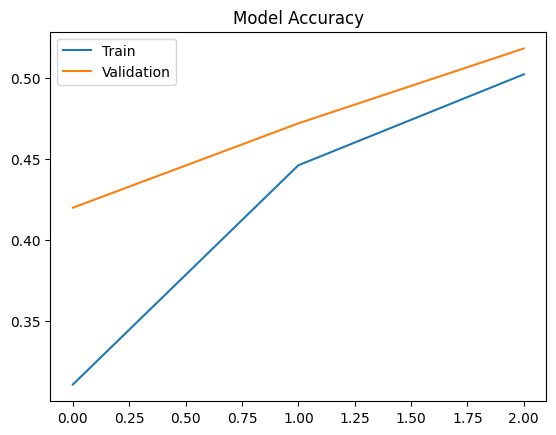

Model saved!

Upload a face image to predict emotion


Saving happy.jpeg to happy (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


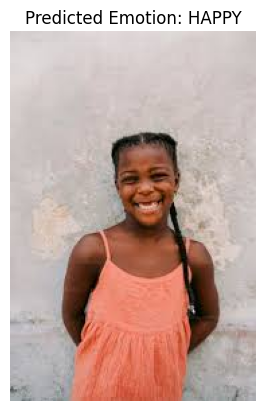

Detected Emotion → HAPPY
Opening a 'happy' song for you → https://www.youtube.com/watch?v=ZbZSe6N_BXs


False

In [ ]:
# FACIAL EMOTION RECOGNITION + MOOD MUSIC SYSTEM
!pip install -q kaggle tensorflow keras keras-tuner opencv-python matplotlib python-vlc pytube

import os, zipfile, cv2, random, webbrowser
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from google.colab import files
import tensorflow as tf

# STEP 1: UPLOAD KAGGLE JSON
print("Please upload your 'kaggle.json' file (from Kaggle Account → API → Create New Token)")
uploaded = files.upload()
if not uploaded:
    raise FileNotFoundError("No file uploaded. Please upload kaggle.json before continuing.")

# Get the actual uploaded file name
kaggle_json_filename = list(uploaded.keys())[0]
if 'kaggle.json' not in kaggle_json_filename:
    print(f"Warning: Expected 'kaggle.json', but received '{kaggle_json_filename}'. Proceeding with the uploaded file.")

!mkdir -p ~/.kaggle
!cp "{kaggle_json_filename}" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API key configured!")

# STEP 2: DOWNLOAD AND EXTRACT FER2013
!kaggle datasets download -d msambare/fer2013 -q --force
if not os.path.exists("fer2013"):
    with zipfile.ZipFile("fer2013.zip","r") as z: z.extractall("fer2013")

if not (os.path.exists("fer2013/train") and os.path.exists("fer2013/test")):
    raise FileNotFoundError("FER2013 dataset folders missing.")
print("Dataset ready!")

# STEP 3: DATA LOADING & PREPROCESSING
img_size=(48,48); batch_size=64
train_gen=ImageDataGenerator(rescale=1./255)
test_gen=ImageDataGenerator(rescale=1./255)

train_data=train_gen.flow_from_directory("fer2013/train",
    target_size=img_size,color_mode="grayscale",class_mode="categorical",batch_size=batch_size)
test_data=test_gen.flow_from_directory("fer2013/test",
    target_size=img_size,color_mode="grayscale",class_mode="categorical",batch_size=batch_size)

emotion_labels=list(train_data.class_indices.keys())
num_classes=len(emotion_labels)
print("Emotion classes:",emotion_labels)

# STEP 4: CNN MODEL
model=models.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',input_shape=(48,48,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

# STEP 5: TRAIN MODEL
history=model.fit(train_data,validation_data=test_data,epochs=3)

plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title("Model Accuracy")
plt.legend(); plt.show()

model.save("emotion_model.h5")
print("Model saved!")

# STEP 6: UPLOAD AND PREDICT SINGLE IMAGE
print("\nUpload a face image to predict emotion")
uploaded_img=files.upload()
img_path=list(uploaded_img.keys())[0]

model=load_model("emotion_model.h5")
img=cv2.imread(img_path)
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
face=cv2.resize(gray,(48,48))/255.0
face=np.reshape(face,(1,48,48,1))
pred=model.predict(face)
emotion=emotion_labels[np.argmax(pred)]

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Predicted Emotion: {emotion.upper()}")
plt.show()
print(f"Detected Emotion → {emotion.upper()}")

# STEP 7: MOOD-BASED MUSIC PLAYLIST
music_library={
    "happy":[
        "https://www.youtube.com/watch?v=ZbZSe6N_BXs",
        "https://www.youtube.com/watch?v=d-diB65scQU"
    ],
    "sad":[
        "https://www.youtube.com/watch?v=RBumgq5yVrA",
        "https://www.youtube.com/watch?v=hoNb6HuNmU0"
    ],
    "angry":[
        "https://www.youtube.com/watch?v=8SbUC-UaAxE",
        "https://www.youtube.com/watch?v=3YxaaGgTQYM"
    ],
    "surprise":[
        "https://www.youtube.com/watch?v=2Vv-BfVoq4g",
        "https://www.youtube.com/watch?v=JGwWNGJdvx8"
    ],
    "neutral":[
        "https://www.youtube.com/watch?v=ktvTqknDobU",
        "https://www.youtube.com/watch?v=09R8_2nJtjg"
    ],
    "fear":[
        "https://www.youtube.com/watch?v=2vjPBrBU-TM",
        "https://www.youtube.com/watch?v=lWA2pjMjpBs"
    ],
    "disgust":[
        "https://www.youtube.com/watch?v=uelHwf8o7_U",
        "https://www.youtube.com/watch?v=kOkQ4T5WO9E"
    ]
}

# choose playlist based on emotion (if not present → neutral)
playlist=music_library.get(emotion.lower(),music_library["neutral"])
song=random.choice(playlist)
print(f"Opening a '{emotion}' song for you → {song}")
webbrowser.open(song)